# Data Leakage in Aptamer–Protein Interaction Benchmarks

**Companion analysis for *"Protein overlap inflates apparent generalization in aptamer–protein interaction benchmarks
"***

This notebook reproduces the central empirical claims of the paper: that headline
performance on the Li et al. aptamer–protein benchmark is driven by
**protein-identity pair memorization**, not generalizable binding prediction. When the
same protein may appear in both training and test folds (standard CV), classifiers
score well; when proteins are held disjoint between folds, performance collapses to
near-random even in deep learning approaches.


## 0. Configuration & imports

`DATA_PATH` points at `dataset_li.pickle`. Everything is reproducible from
`RANDOM_SEED`. `MMSEQS_THRESHOLD` and `NEG_RATIO` control the homology-cluster
identity cutoff and the negatives-per-positive ratio used when regenerating negatives.

In [1]:
import os
import re
import copy
import subprocess
import numpy as np
import pandas as pd

# ---- Config ----
DATA_PATH       = "datasets/dataset_li.pickle"
K_FOLDS         = 5
RANDOM_SEED     = 42
MMSEQS_THRESHOLD = 0.8     # protein homology-cluster identity cutoff
NEG_RATIO       = 3        # negatives generated per positive, within each fold
USE_MMSEQS      = True     # if False, fall back to exact-protein grouping

rng = np.random.default_rng(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Palette
BLUE_DARK, BLUE_MED, BLUE_LIGHT = "#1E3A5F", "#2563EB", "#60A5FA"
ORANGE = "#EA7317" 

## 1. Features — k-mer encoding

We use the **same feature representation common in the aptamer-ML literature**:
length-normalized k-mer frequency vectors. Aptamers are encoded as RNA 4-mers
(T→U); proteins are reduced to a 7-letter conjoint-triad alphabet and encoded as
3-mers. No structural or learned features as the point is that *even with identical
features*, the only thing that changes results is the split protocol. Kmers were chosen as they are simple and standard for workflows.

In [2]:
# Conjoint-triad 7-group amino-acid reduction -> letters A..G
_PROT_GROUPS = [
    ("A","G","V"), ("I","L","F","P"), ("Y","M","T","S"),
    ("H","N","Q","W"), ("R","K"), ("D","E"), ("C",),
]
_PROT_MAP = {aa: chr(ord("A")+i) for i, g in enumerate(_PROT_GROUPS) for aa in g}

def _build_index(alphabet, kmax):
    """Return (maps, offsets, total_width) for k=1..kmax over alphabet."""
    maps, sizes = [], []
    for k in range(1, kmax+1):
        kmers = [""]
        for _ in range(k):
            kmers = [p+ch for p in kmers for ch in alphabet]
        maps.append({km: i for i, km in enumerate(kmers)})
        sizes.append(len(kmers))
    sizes_arr = np.asarray(sizes, dtype=np.int64)
    offsets = np.array([int(sizes_arr[:i].sum()) for i in range(kmax)], dtype=np.int64)
    return maps, offsets, int(sizes_arr.sum())

def _count_one(seq, maps, offsets, kmax, total):
    """Length-normalized concatenated k-mer count vector for one sequence."""
    counts = np.zeros(total, dtype=np.float32)
    L = len(seq)
    for m in range(kmax):
        mer, off, km = m+1, offsets[m], maps[m]
        for i in range(L - mer + 1):
            j = km.get(seq[i:i+mer])
            if j is not None:
                counts[off + j] += 1.0
    return counts / max(1, L)

def _clean_aptamer(seq):
    """Keep only nucleotides, normalize T->U for aptamers."""
    return re.sub(r"[^ACGU]", "", str(seq).upper().replace("T", "U"))

def extract_protein_features(proteins, k=3):
    maps, offsets, total = _build_index(list("ABCDEFG"), k)
    out = np.zeros((len(proteins), total), dtype=np.float32)
    for i, p in enumerate(proteins):
        s = "".join(_PROT_MAP.get(a, a) for a in str(p))
        out[i] = _count_one(s, maps, offsets, k, total)
    return out

def extract_aptamer_features(aptamers, k=4):
    maps, offsets, total = _build_index(list("ACGU"), k)
    out = np.zeros((len(aptamers), total), dtype=np.float32)
    for i, a in enumerate(aptamers):
        out[i] = _count_one(_clean_aptamer(a), maps, offsets, k, total)
    return out

def build_features_kmer(frame):
    """Feature matrix for a frame with 'aptamer' and 'protein' columns."""
    apt  = extract_aptamer_features(frame["aptamer"].tolist(), k=4)
    prot = extract_protein_features(frame["protein"].tolist(), k=3)
    return np.hstack([apt, prot]).astype(np.float32)

## 2. Load data and inspect the *provided* split

First we quantify the leakage in the benchmark's own train/test split: how many
test pairs are exact duplicates of training pairs, and how many test pairs share a
protein with training. This is the basis for the paper's **99.83% overlap** claim.

In [3]:
data = pd.read_pickle(DATA_PATH)
print(f"Loaded: {len(data)} rows | columns: {list(data.columns)}")
print(f"Unique proteins : {data['protein'].nunique()}")
print(f"Unique aptamers : {data['aptamer'].nunique()}")

def inspect_leakage(df):
    ds = df["dataset"].astype(str).str.lower()
    train, test = df[ds.str.contains("train")], df[ds.str.contains("test")]
    train_pairs = set(zip(train["aptamer"], train["protein"]))
    train_prots = set(train["protein"])
    n_exact   = int(test.apply(lambda r: (r["aptamer"], r["protein"]) in train_pairs, axis=1).sum())
    n_overlap = int(test["protein"].isin(train_prots).sum())
    n_test    = len(test)
    pct = n_overlap / n_test * 100 if n_test else 0.0
    print("="*56)
    print("LEAKAGE INSPECTION (provided split)")
    print("="*56)
    print(f"Provided train/test     : {len(train)} / {n_test}")
    print(f"  Exact pair duplicates : {n_exact}")
    print(f"  Protein overlap       : {n_overlap}/{n_test} ({pct:.2f}%)")
    print(f"  Truly held-out pairs  : {n_test - n_overlap}")
    return {"n_test": n_test, "n_protein_overlap": n_overlap,
            "n_exact": n_exact, "pct_overlap": pct}

leakage_stats = inspect_leakage(data)

Loaded: 2900 rows | columns: ['label', 'aptamer', 'protein', 'dataset']
Unique proteins : 144
Unique aptamers : 709
LEAKAGE INSPECTION (provided split)
Provided train/test     : 2320 / 580
  Exact pair duplicates : 6
  Protein overlap       : 579/580 (99.83%)
  Truly held-out pairs  : 1


## 3. Build leakage-safe folds (positives only) + protein homology clusters

We keep **only the positive pairs**, then cluster proteins by homology with MMseqs2
(identity ≥ `MMSEQS_THRESHOLD`) so that homologous proteins are never split across
folds. `StratifiedGroupKFold` on the positives, grouped by cluster, gives folds in
which no test protein shares ≥80% identity with any train protein. Negatives are
**not** created here — they are regenerated inside each fold in the next step.

In [4]:
from sklearn.model_selection import StratifiedGroupKFold

# Keep positives only; binarize defensively
def is_pos(lab):
    if pd.api.types.is_numeric_dtype(type(lab)):
        return float(lab) > 0
    return str(lab).strip().lower() == "positive"

pos = data[data["label"].apply(is_pos)].copy()
pos = pos.drop_duplicates(subset=["aptamer", "protein"]).reset_index(drop=True)
print(f"Positive, de-duplicated pairs: {len(pos)} over {pos['protein'].nunique()} proteins")

def cluster_proteins_mmseqs(proteins, threshold):
    """Return dict protein->cluster_rep using MMseqs2 easy-cluster."""
    uniq = pd.Series(sorted(set(proteins)))
    with open("proteins.fasta", "w") as f:
        for i, p in enumerate(uniq):
            f.write(f">protein_{i}\n{p}\n")
    subprocess.run(
        ["mmseqs", "easy-cluster", "proteins.fasta", "clusters", "tmp",
         "--min-seq-id", str(threshold), "-c", "0.8", "--cov-mode", "0",
         "--cluster-mode", "2", "--threads", "8"],
        check=True, capture_output=True,
    )
    cl = pd.read_csv("clusters_cluster.tsv", sep="\t", header=None, names=["rep", "member"])
    idx_to_prot = {f"protein_{i}": p for i, p in enumerate(uniq)}
    return {idx_to_prot[m]: r for r, m in zip(cl["rep"], cl["member"])}

if USE_MMSEQS:
    try:
        prot_to_cluster = cluster_proteins_mmseqs(pos["protein"], MMSEQS_THRESHOLD)
        pos["group"] = pos["protein"].map(prot_to_cluster)
        n_groups = pos["group"].nunique()
        print(f"MMseqs2 clusters: {n_groups} (from {pos['protein'].nunique()} proteins)")
    except Exception as e:
        print(f"MMseqs2 unavailable ({e}); falling back to exact-protein grouping.")
        pos["group"] = pos["protein"]
else:
    pos["group"] = pos["protein"]

# Group-disjoint folds over positives
sgkf = StratifiedGroupKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
pos_folds = list(sgkf.split(pos, np.zeros(len(pos)), groups=pos["group"]))

# Sanity: no group shared across any fold boundary
for i, (tr, te) in enumerate(pos_folds):
    overlap = set(pos.iloc[tr]["group"]) & set(pos.iloc[te]["group"])
    assert not overlap, f"Fold {i} has group leakage: {len(overlap)} shared clusters"
print("All folds verified protein-cluster-disjoint (0 shared clusters).")

Positive, de-duplicated pairs: 710 over 144 proteins
MMseqs2 clusters: 139 (from 144 proteins)
All folds verified protein-cluster-disjoint (0 shared clusters).


## 4. Per-fold negative regeneration

For each fold we build train and test sets **independently**:

- Positives come from that fold's positive split.
- Negatives are generated by shuffling each positive aptamer (preserving length and
  composition) and pairing it with a protein **drawn from the same fold's protein
  pool**. A train negative never uses a test-fold protein, and vice-versa.

This guarantees that no protein identity — through either a positive or a negative —
crosses the train/test boundary. We generate `NEG_RATIO` negatives per positive.

In [5]:
def make_negatives(pos_frame, protein_pool, ratio, rng=rng):
    """Random-pairing negatives (Li et al. 2014 style), regenerated within a fold.

    Keeps each aptamer's sequence intact and pairs it with proteins it does NOT
    bind, drawn only from `protein_pool` (this fold's proteins) so nothing crosses
    the train/test boundary. Negative proteins are spread near-uniformly via
    usage-balancing rather than pure random draw.
    """
    pool = np.array(sorted(set(protein_pool)))

    apt_binds = pos_frame.groupby("aptamer")["protein"].apply(set).to_dict()
    usage = {p: 0 for p in pool}

    rows = []
    for _, r in pos_frame.iterrows():
        apt = r["aptamer"]
        bound = apt_binds.get(apt, set())
        candidates = np.array([p for p in pool if p not in bound])
        if candidates.size == 0:
            continue
        k = min(ratio, candidates.size)

        # Prefer least-used proteins; random tie-break
        counts = np.array([usage[p] for p in candidates])
        jitter = rng.random(candidates.size)
        order = np.lexsort((jitter, counts))
        chosen = candidates[order[:k]]

        for prot in chosen:
            usage[prot] += 1
            rows.append({"label": 0, "aptamer": apt, "protein": prot})

    return pd.DataFrame(rows).drop_duplicates(subset=["aptamer", "protein"])


def assemble_fold(tr_idx, te_idx):
    """Return (X_tr, y_tr, X_te, y_te, te_frame) with leakage-safe negatives."""
    tr_pos = pos.iloc[tr_idx][["aptamer", "protein"]].copy(); tr_pos["label"] = 1
    te_pos = pos.iloc[te_idx][["aptamer", "protein"]].copy(); te_pos["label"] = 1

    tr_neg = make_negatives(tr_pos, tr_pos["protein"].tolist(), NEG_RATIO)
    te_neg = make_negatives(te_pos, te_pos["protein"].tolist(), NEG_RATIO)

    tr = pd.concat([tr_pos, tr_neg], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)
    te = pd.concat([te_pos, te_neg], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)

    X_tr, y_tr = build_features_kmer(tr), tr["label"].to_numpy()
    X_te, y_te = build_features_kmer(te), te["label"].to_numpy()
    return X_tr, y_tr, X_te, y_te, te


# Precompute the disjoint folds (leakage-safe) once
disjoint_folds = [assemble_fold(tr, te) for tr, te in pos_folds]
print(f"Built {len(disjoint_folds)} leakage-safe disjoint folds (random-pairing, "
      f"NEG_RATIO={NEG_RATIO}).")
print("Example fold (train,test) sizes:",
      [(len(f[1]), len(f[3])) for f in disjoint_folds])

Built 5 leakage-safe disjoint folds (random-pairing, NEG_RATIO=3).
Example fold (train,test) sizes: [(2268, 572), (2284, 556), (2276, 564), (2242, 596), (2288, 552)]


### Saving to CSVs for Aptatrans rerun

In [6]:
def assemble_fold(tr_idx, te_idx, fold_id=None):
    """Return a single DataFrame for this fold: columns [fold, label, aptamer, protein]."""
    tr_pos = pos.iloc[tr_idx][["aptamer", "protein"]].copy(); tr_pos["label"] = 1
    te_pos = pos.iloc[te_idx][["aptamer", "protein"]].copy(); te_pos["label"] = 1

    tr_neg = make_negatives(tr_pos, tr_pos["protein"].tolist(), NEG_RATIO)
    te_neg = make_negatives(te_pos, te_pos["protein"].tolist(), NEG_RATIO)

    tr = pd.concat([tr_pos, tr_neg], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)
    te = pd.concat([te_pos, te_neg], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED)
    tr["dataset"], te["dataset"] = "training dataset", "test dataset"

    fold = pd.concat([tr, te], ignore_index=True)
    fold["fold"] = fold_id
    fold["label"] = np.where(fold["label"] == 1, "positive", "negative")
    return fold[["fold", "dataset", "label", "aptamer", "protein"]]


def fold_xy(fold_df, split):
    """Materialize (X, y, frame) for one split of a fold DataFrame."""
    sub = fold_df[fold_df["split"] == split].reset_index(drop=True)
    return build_features_kmer(sub), sub["label"].to_numpy(), sub

disjoint_folds_aptatrans = [assemble_fold(tr, te, i) for i, (tr, te) in enumerate(pos_folds)]
num = 1
for fold in disjoint_folds_aptatrans:
    
    fold.to_csv("datasets/resplit/Fold_"+str(num)+".csv")
    num += 1

### Standard (leaky) folds for contrast

To show the *gap*, we also build standard folds where the **same negative-regeneration
procedure** is used, but proteins are allowed to repeat across folds (ordinary
`StratifiedKFold` on positives, ignoring the group constraint). The negative
construction is held identical between protocols so that the **only** difference is
whether proteins are held disjoint — isolating leakage as the cause.

In [7]:
from sklearn.model_selection import StratifiedKFold

# --- Standard protocol: faithful Li et al. (2014) reproduction ---
# Negatives are generated ONCE over the full positive set by random pairing
# (3:1), then positives+negatives are split together by ordinary random k-fold.
# No protein-disjoint constraint and no per-fold regeneration: this is the
# leaky baseline exactly as the benchmark constructs it.

all_neg = make_negatives(pos[["aptamer", "protein"]].assign(label=1),
                         pos["protein"].tolist(), NEG_RATIO)
full = pd.concat([pos[["aptamer", "protein"]].assign(label=1), all_neg],
                 ignore_index=True)

X_full = build_features_kmer(full)
y_full = full["label"].to_numpy()

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=RANDOM_SEED)
standard_folds = []
for tr_idx, te_idx in skf.split(X_full, y_full):
    standard_folds.append((
        X_full[tr_idx], y_full[tr_idx],
        X_full[te_idx], y_full[te_idx],
        full.iloc[te_idx],
    ))

print(f"Built {len(standard_folds)} standard (Li et al.) folds "
      f"(global negatives, random split, NEG_RATIO={NEG_RATIO}).")
print("Example fold (train,test) sizes:",
      [(len(f[1]), len(f[3])) for f in standard_folds])

Built 5 standard (Li et al.) folds (global negatives, random split, NEG_RATIO=3).
Example fold (train,test) sizes: [(2272, 568), (2272, 568), (2272, 568), (2272, 568), (2272, 568)]


## 5. Classifiers

A panel of standard classifiers reported in the aptamer-ML literature. All use
balanced class weights, standard scaling, and a variance-threshold step.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.pipeline import Pipeline
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              HistGradientBoostingClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier)
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def build_classifiers():
    return {
        "RandomForest":       RandomForestClassifier(class_weight="balanced", n_jobs=6, random_state=42),
        "ExtraTrees":         ExtraTreesClassifier(class_weight="balanced", n_jobs=6, random_state=42),
        "HistGB":             HistGradientBoostingClassifier(class_weight="balanced", random_state=42),
        "GradientBoosting":   GradientBoostingClassifier(random_state=42),
        "LogisticRegression": LogisticRegression(penalty="l2", class_weight="balanced",
                                                 solver="saga", max_iter=5000, n_jobs=6, random_state=42),
        "SVC":                SVC(kernel="rbf", class_weight="balanced", probability=False, random_state=42),
        "KNN":                KNeighborsClassifier(n_neighbors=10, weights="distance", n_jobs=6),
        "XGBoost": XGBClassifier(eval_metric="logloss", n_jobs=6, random_state=42), 
        "LightGBM": LGBMClassifier(n_jobs=6, random_state=42, verbose=-1)
    }

def make_pipe(clf):
    return Pipeline([("vt", VarianceThreshold(0.0)),
                     ("scaler", StandardScaler()),
                     ("clf", clf)])

## 6. Standard vs protein-disjoint CV

For each classifier we score MCC under both protocols using the **identical
negative-construction procedure**, so the contrast isolates the effect of protein
disjointness. A stratified dummy anchors the floor.

In [9]:
from pathlib import Path
from sklearn.metrics import matthews_corrcoef, roc_auc_score
from sklearn.dummy import DummyClassifier
from pathlib import Path

def _scores_for_auc(fitted_pipe, X):
    """Return continuous scores for AUC: proba if available, else decision_function."""
    if hasattr(fitted_pipe, "predict_proba"):
        return fitted_pipe.predict_proba(X)[:, 1]
    if hasattr(fitted_pipe, "decision_function"):
        return fitted_pipe.decision_function(X)
    # last resort: hard labels (AUC will be degenerate, but won't crash)
    return fitted_pipe.predict(X)

def score_assembled(clf, folds):
    mccs, aucs = [], []
    for X_tr, y_tr, X_te, y_te, _ in folds:
        p = make_pipe(copy.deepcopy(clf))
        p.fit(X_tr, y_tr)
        y_pred = p.predict(X_te)
        mccs.append(matthews_corrcoef(y_te, y_pred))
        # AUC is undefined if a fold's test set is single-class; guard it
        if len(np.unique(y_te)) < 2:
            aucs.append(np.nan)
        else:
            aucs.append(roc_auc_score(y_te, _scores_for_auc(p, X_te)))
    return np.asarray(mccs, dtype=float), np.asarray(aucs, dtype=float)

clfs = build_classifiers()

if not Path('results/models_results.csv').is_file():
    rows = []
    for name, clf in clfs.items():
        mcc_std, auc_std = score_assembled(clf, standard_folds)
        mcc_dis, auc_dis = score_assembled(clf, disjoint_folds)
        rows.append({
            "Model": name,
            "Standard_MCC": mcc_std.mean(), "Standard_MCC_Std": mcc_std.std(),
            "Disjoint_MCC": mcc_dis.mean(), "Disjoint_MCC_Std": mcc_dis.std(),
            "MCC_Drop": mcc_std.mean() - mcc_dis.mean(),
            "Standard_AUC": np.nanmean(auc_std), "Standard_AUC_Std": np.nanstd(auc_std),
            "Disjoint_AUC": np.nanmean(auc_dis), "Disjoint_AUC_Std": np.nanstd(auc_dis),
            "AUC_Drop": np.nanmean(auc_std) - np.nanmean(auc_dis),
        })
        print(f"  {name:<18} "
              f"MCC {mcc_std.mean():+.3f}->{mcc_dis.mean():+.3f}   "
              f"AUC {np.nanmean(auc_std):.3f}->{np.nanmean(auc_dis):.3f}")
    
    # Dummy floor for both metrics
    dummy = DummyClassifier(strategy="stratified", random_state=RANDOM_SEED)
    def dummy_scores(folds):
        mccs, aucs = [], []
        for X_tr, y_tr, X_te, y_te, _ in folds:
            d = dummy.fit(X_tr, y_tr)
            mccs.append(matthews_corrcoef(y_te, d.predict(X_te)))
            if len(np.unique(y_te)) < 2:
                aucs.append(np.nan)
            else:
                aucs.append(roc_auc_score(y_te, d.predict_proba(X_te)[:, 1]))
        return np.nanmean(mccs), np.nanmean(aucs)
    
    d_std_mcc, d_std_auc = dummy_scores(standard_folds)
    d_dis_mcc, d_dis_auc = dummy_scores(disjoint_folds)
    rows.append({
        "Model": "Dummy",
        "Standard_MCC": d_std_mcc, "Standard_MCC_Std": 0.0,
        "Disjoint_MCC": d_dis_mcc, "Disjoint_MCC_Std": 0.0,
        "MCC_Drop": d_std_mcc - d_dis_mcc,
        "Standard_AUC": d_std_auc, "Standard_AUC_Std": 0.0,
        "Disjoint_AUC": d_dis_auc, "Disjoint_AUC_Std": 0.0,
        "AUC_Drop": d_std_auc - d_dis_auc,
    })
    
    results_df = (pd.DataFrame(rows)
                  .sort_values("Standard_MCC", ascending=False)
                  .reset_index(drop=True))
    results_df.to_csv("models_results.csv", index=False)
else:
    results_df = pd.read_csv("results/models_results.csv")
results_df

,Model,Standard_MCC,Standard_MCC_Std,Disjoint_MCC,Disjoint_MCC_Std,MCC_Drop,Standard_AUC,Standard_AUC_Std,Disjoint_AUC,Disjoint_AUC_Std,AUC_Drop
0,ExtraTrees,0.594574,0.028827,0.000000,0.000000,0.594574,0.837464,0.032395,0.509241,0.034028,0.328223
1,RandomForest,0.513621,0.027559,0.000000,0.000000,0.513621,0.813278,0.028959,0.497344,0.016534,0.315934
2,XGBoost,0.499098,0.037547,0.004867,0.043994,0.494231,0.785707,0.028902,0.517331,0.035711,0.268377
3,LightGBM,0.488315,0.036035,0.006217,0.012433,0.482099,0.779905,0.027959,0.488377,0.023741,0.291528
4,HistGB,0.472056,0.054662,-0.001775,0.039668,0.473831,0.773725,0.039857,0.501558,0.046532,0.272168
5,SVC,0.350466,0.040196,-0.006952,0.032855,0.357417,0.711006,0.031648,0.490766,0.032374,0.220240
6,GradientBoosting,0.327861,0.030615,0.009921,0.021530,0.317941,0.704840,0.034621,0.507178,0.074134,0.197663
7,KNN,0.289764,0.037711,0.006491,0.030214,0.283273,0.675129,0.025523,0.490096,0.035452,0.185033
8,LogisticRegression,0.037889,0.050627,-0.001032,0.060282,0.038922,0.519993,0.037551,0.485901,0.027315,0.034092
9,Dummy,-0.004573,0.000000,-0.020011,0.000000,0.015438,0.497653,0.000000,0.489981,0.000000,0.007672


## 7. Figure 1 — MCC under standard vs protein-disjoint CV
Bars show mean MCC per classifier under each protocol; error bars are the standard deviation across folds. The collapse of the disjoint bars toward (and below) zero is the visual statement of the result.

Saved fig_mcc_comparison.svg and fig_mcc_comparison.png


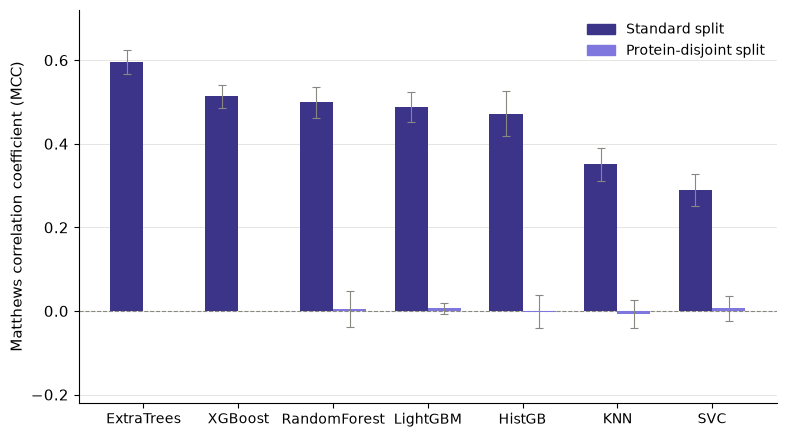

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data ──────────────────────────────────────────────────────────────────────
models = ["ExtraTrees", "XGBoost", "RandomForest", "LightGBM", "HistGB", "KNN", "SVC"]

standard_mcc = results_df[results_df["Model"].isin(models)]["Standard_MCC"].tolist()
standard_std = results_df[results_df["Model"].isin(models)]["Standard_MCC_Std"].tolist()
disjoint_mcc = results_df[results_df["Model"].isin(models)]["Disjoint_MCC"].tolist()
disjoint_std = results_df[results_df["Model"].isin(models)]["Disjoint_MCC_Std"].tolist()

# replace zero std with nan so matplotlib skips the error bar entirely
std_std_plot = [s if s > 0 else np.nan for s in standard_std]
dis_std_plot = [s if s > 0 else np.nan for s in disjoint_std]

# ── Style ─────────────────────────────────────────────────────────────────────
PURPLE_DARK  = "#3C3489"
PURPLE_LIGHT = "#7F77DD"
GRAY         = "#888780"

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.size":       11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":  0.8,
})

# Layout 
fig, ax = plt.subplots(figsize=(8, 4.5))

x = np.arange(len(models))
w = 0.35

bars_std = ax.bar(
    x - w/2, standard_mcc, w,
    color=PURPLE_DARK, yerr=std_std_plot,
    error_kw=dict(ecolor=GRAY, elinewidth=0.8, capsize=3, capthick=0.8),
    zorder=3
)
bars_dis = ax.bar(
    x + w/2, disjoint_mcc, w,
    color=PURPLE_LIGHT, yerr=dis_std_plot,
    error_kw=dict(ecolor=GRAY, elinewidth=0.8, capsize=3, capthick=0.8),
    zorder=3
)

# zero line
ax.axhline(0, color=GRAY, linewidth=0.8, linestyle="--", zorder=2)

# Axes 
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=10)
ax.set_ylabel("Matthews correlation coefficient (MCC)", fontsize=11)
ax.set_ylim(-0.22, 0.72)
ax.yaxis.set_major_locator(plt.MultipleLocator(0.2))
ax.grid(axis="y", color=GRAY, alpha=0.25, linewidth=0.6, zorder=1)

# Legend 
legend_handles = [
    mpatches.Patch(color=PURPLE_DARK,  label="Standard split"),
    mpatches.Patch(color=PURPLE_LIGHT, label="Protein-disjoint split"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10, loc="upper right")

plt.tight_layout()
plt.savefig("figures/fig_1.svg", dpi=300, bbox_inches="tight")
plt.savefig("figures/fig_1.png", dpi=300, bbox_inches="tight")
print("Saved fig_mcc_comparison.svg and fig_mcc_comparison.png")
plt.show()

In [11]:
import numpy as np
print(np.mean(standard_mcc))
print()
print(np.mean(disjoint_mcc))

0.45827042825518877

0.001263892806829043


## 8. Figure 2, AptaTrans Rerun

AptaTrans was rerun on the resplit datasets. The only modification made to the original code was the addition of print statements to report MCC and AUC values during training. Because the AptaTrans model is large and requires a GPU (an A100 was used here), its environment configuration is not included in this repository. The aptatrans_rerun.csv  contains the values we report. The data in Figure 2c was obtained by evaluating the best model reported by the AptaTrans authors on their default test set.

Max AUC: 0.519122
Max MCC: 0.109403


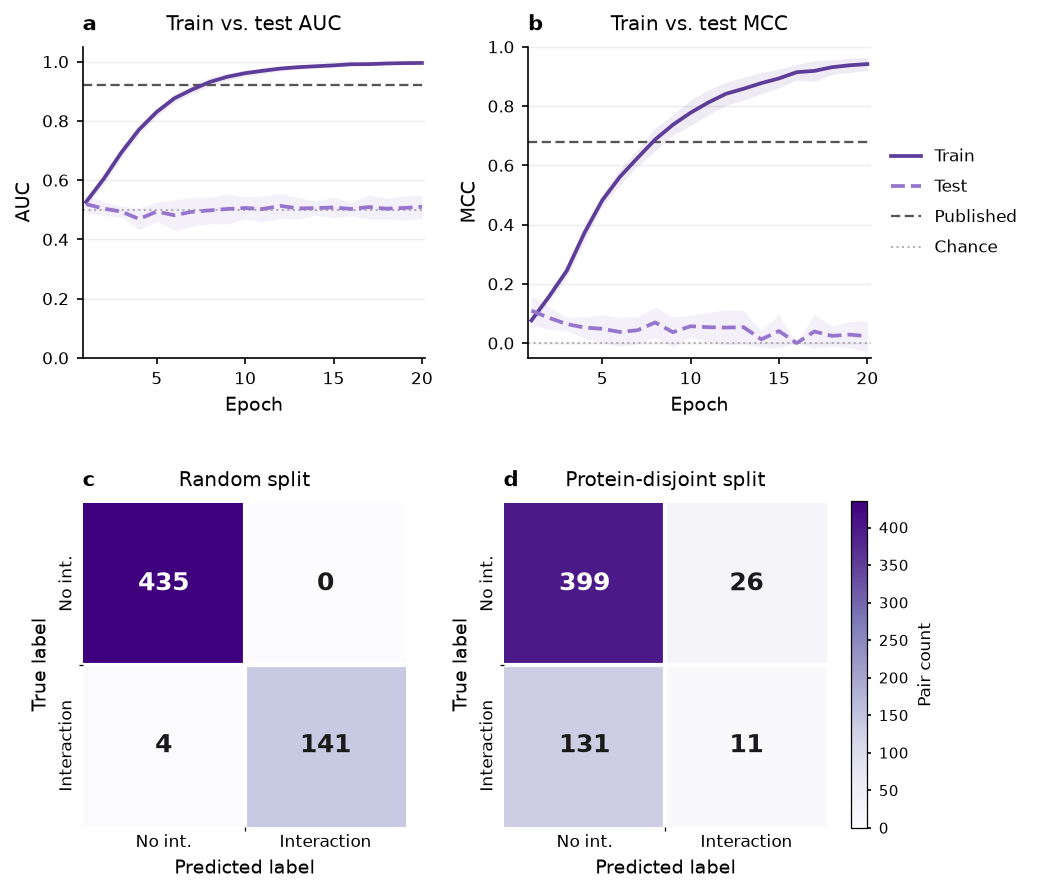

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titlepad": 8,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.frameon": False,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

C_TRAIN = "#5e3c99"  
C_TEST  = "#9575cd"   
C_PUB   = "#555555"   
C_REF   = "#b3b3b3" 
CMAP    = "Purples"

#data
df = pd.read_csv("results/aptatrans_training_log.csv")
epochs    = df["epoch"].values
train_auc = df["train_auc_mean"].values
test_auc  = df["test_auc_mean"].values
train_mcc = df["train_mcc_mean"].values
test_mcc  = df["test_mcc_mean"].values

train_auc_std = df["train_auc_std"].values
test_auc_std  = df["test_auc_std"].values
train_mcc_std = df["train_mcc_std"].values
test_mcc_std  = df["test_mcc_std"].values

print("Max AUC:", test_auc.max())
print("Max MCC:", test_mcc.max())

PUB_AUC = 0.921
PUB_MCC = 0.679

#These two values were copied from AptaTrans anyalsis
cm_random   = np.array([[435, 0], [4, 141]])
cm_disjoint = np.array([[399, 26], [131, 11]]) #fold 1

CM_VMAX = max(cm_random.max(), cm_disjoint.max())

# ----------------------------- figure -----------------------------
fig = plt.figure(figsize=(7.4, 6.2))
gs = GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.30,
              height_ratios=[1.0, 1.05], left=0.09, right=0.80,
              top=0.93, bottom=0.09)


def style_curve_axes(ax):
    ax.grid(axis="y", color="#ededed", linewidth=0.7, zorder=0)
    ax.set_axisbelow(True)
    ax.margins(x=0.01)
    ax.tick_params(length=3)

def add_band(ax, x, mean, std, color, lo=None, hi=None):
    upper = mean + std
    lower = mean - std
    if lo is not None or hi is not None:
        upper = np.clip(upper, lo, hi)
        lower = np.clip(lower, lo, hi)
    ax.fill_between(x, lower, upper, color=color, alpha=0.1,
                    linewidth=0, zorder=2)
    
# ---- Panel A: AUC ----
axA = fig.add_subplot(gs[0, 0])
axA.plot(epochs, train_auc, color=C_TRAIN, lw=1.8, zorder=3)
add_band(axA, epochs, train_auc, train_auc_std, C_TRAIN, 0.0, 1.0)
axA.plot(epochs, test_auc, color=C_TEST, lw=1.8, ls="--", zorder=3)
add_band(axA, epochs, test_auc, test_auc_std, C_TEST, 0.0, 1.0)
axA.axhline(PUB_AUC, color=C_PUB, lw=1.1, ls=(0, (4, 2)), zorder=2)
axA.axhline(0.5,     color=C_REF, lw=1.0, ls=":", zorder=1)
axA.set_ylim(0.0, 1.05)
axA.yaxis.set_major_locator(MultipleLocator(0.2))
axA.set_xlabel("Epoch")
axA.set_ylabel("AUC")
axA.set_title("a", loc="left", fontweight="bold")
axA.set_title("Train vs. test AUC", loc="center", fontsize=9.5)
style_curve_axes(axA)

# ---- Panel B: MCC ----
axB = fig.add_subplot(gs[0, 1])
axB.plot(epochs, train_mcc, color=C_TRAIN, lw=1.8, zorder=3)
add_band(axB, epochs, train_mcc, train_mcc_std, C_TRAIN, -1.0, 1.0)
axB.plot(epochs, test_mcc, color=C_TEST, lw=1.8, ls="--", zorder=3)
add_band(axB, epochs, test_mcc, test_mcc_std, C_TEST, -1.0, 1.0)
axB.axhline(PUB_MCC, color=C_PUB, lw=1.1, ls=(0, (4, 2)), zorder=2)
axB.axhline(0.0,     color=C_REF, lw=1.0, ls=":", zorder=1)
axB.set_ylim(-0.05, 1.0)
axB.yaxis.set_major_locator(MultipleLocator(0.2))
axB.set_xlabel("Epoch")
axB.set_ylabel("MCC")
axB.set_title("b", loc="left", fontweight="bold")
axB.set_title("Train vs. test MCC", loc="center", fontsize=9.5)
style_curve_axes(axB)

# ---- shared legend, outside top row to the right ----
legend_handles = [
    Line2D([0], [0], color=C_TRAIN, lw=1.8,            label="Train"),
    Line2D([0], [0], color=C_TEST,  lw=1.8, ls="--",   label="Test"),
    Line2D([0], [0], color=C_PUB,   lw=1.1, ls=(0, (4, 2)),
           label="Published"),
    Line2D([0], [0], color=C_REF,   lw=1.0, ls=":",    label="Chance"),
]
axB.legend(handles=legend_handles, loc="center left",
           bbox_to_anchor=(1.04, 0.5), handlelength=1.8,
           borderaxespad=0.0, labelspacing=0.8)


# ---- confusion-matrix helper ----
def plot_cm(ax, cm, panel, subtitle):
    im = ax.imshow(cm, vmin=0, vmax=CM_VMAX, cmap=CMAP)
    total = cm.sum()
    thresh = CM_VMAX * 0.55
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            txt_color = "white" if v > thresh else "#1a1a1a"
            ax.text(j, i, f"{v:d}", ha="center", va="center",
                    color=txt_color, fontsize=12, fontweight="bold")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["No int.", "Interaction"])
    ax.set_yticklabels(["No int.", "Interaction"], rotation=90, va="center")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(panel, loc="left", fontweight="bold")
    ax.set_title(subtitle, loc="center", fontsize=9.5)
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xticks([0.5], minor=True); ax.set_yticks([0.5], minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    return im


axC = fig.add_subplot(gs[1, 0])
im = plot_cm(axC, cm_random,   "c", "Random split")
axD = fig.add_subplot(gs[1, 1])
plot_cm(axD, cm_disjoint, "d", "Protein-disjoint split")

cbar = fig.colorbar(im, ax=[axC, axD], fraction=0.025, pad=0.03)
cbar.set_label("Pair count", fontsize=8)
cbar.ax.tick_params(labelsize=7, length=2)
cbar.outline.set_linewidth(0.6)

fig.savefig("figures/figure_2.svg")
fig.savefig("figures/figure_2.png")

Rerunning AptaTrans without negative reshuffling causes the model to collapse to a single prediction. This happens because all the aptamers in the test set were already seen as negative examples in the training set.

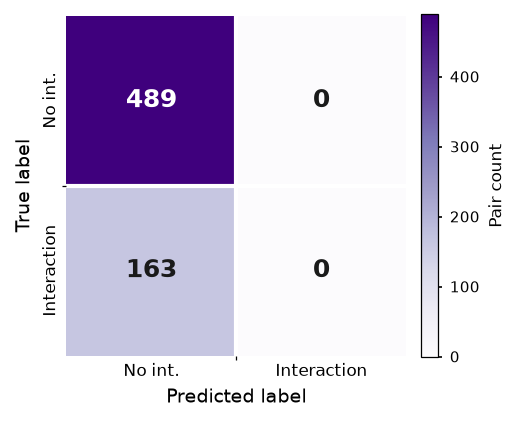

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------- global style -----------------------------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.linewidth": 0.8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

CMAP = "Purples"

# ----------------------------- data -----------------------------
cm_disjoint = np.array([[489, 0], [163, 0]])


# ----------------------------- plot -----------------------------
def plot_cm(ax, cm, cmap=CMAP):
    vmax = cm.max()
    im = ax.imshow(cm, vmin=0, vmax=vmax, cmap=cmap)

    thresh = vmax * 0.55
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            v = cm[i, j]
            ax.text(j, i, f"{v:d}", ha="center", va="center",
                    color="white" if v > thresh else "#1a1a1a",
                    fontsize=12, fontweight="bold")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["No int.", "Interaction"])
    ax.set_yticklabels(["No int.", "Interaction"], rotation=90, va="center")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.tick_params(length=0)
    for s in ax.spines.values():
        s.set_visible(False)

    # white dividing lines between cells
    ax.set_xticks([0.5], minor=True)
    ax.set_yticks([0.5], minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    return im


fig, ax = plt.subplots(figsize=(3.2, 3.2))
im = plot_cm(ax, cm_disjoint)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Pair count", fontsize=8)
cbar.ax.tick_params(labelsize=7, length=2)
cbar.outline.set_linewidth(0.6)

fig.savefig("figures/figure_3.svg")
fig.savefig("figures/figure_3.png")